# DAY - 30
# DATE - 20.06.2026
# Object Detection in Satellite Imagery

In [15]:
# Install the Ultralytics package for YOLO
!pip install ultralytics

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import cv2
import os
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

In [31]:
# Google Drive ka exact file path
drive_image_path = '/content/drive/My Drive/MISSION_RS_SDA/my_satellite_airport_16.jpg'


✅ Damn! Blockbuster! Google Drive se image successfully load ho gayi hai.
--- YOLOv8 Model Load Ho Raha Hai... ---
--- Running Inference on Your Drive Image ---

image 1/1 /content/drive/My Drive/MISSION_RS_SDA/my_satellite_airport_16.jpg: 640x640 1 bench, 7.5ms
Speed: 3.7ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-6

🔥 BOOM! Total 1 Objects Detect Hue Hain!
--- DETAILS ---
🛰️ Class: BENCH | Confidence: 0.21

--- VISUALIZATION WITH BOUNDING BOXES ---


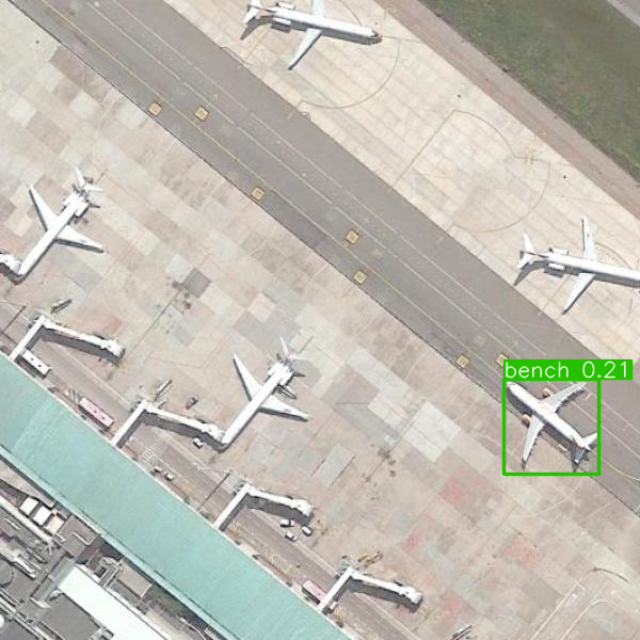

In [33]:
# Verification check ki Colab ko Drive ke andar file mili ya nahi
if os.path.exists(drive_image_path):
    print("✅ Damn! Blockbuster! Google Drive se image successfully load ho gayi hai.")

    # Standard YOLOv8 model load kar rahe hain (Kyunki image standard horizontal boxes wali hai)
    print("--- YOLOv8 Model Load Ho Raha Hai... ---")
    model = YOLO("yolov8n.pt")
    print("--- Running Inference on Your Drive Image ---")

    # Satellite view hai, isliye confidence threshold ko 0.15 rakha hai taaki planes miss na hon
    results = model.predict(source = drive_image_path, conf = 0.15, save = True)

    for results in results:
      boxes = results.boxes

      if len(boxes) == 0:
        print("\nℹ️ Pipeline perfect chala! Par standard model ko top-down view se features samajh nahi aaye.")
        print("\n--- ORIGINAL IMAGE ---")
        orig = cv2.imread(drive_image_path)
        cv2_imshow(cv2.resize(orig, (640, 640)))

      else:
          print(f"\n🔥 BOOM! Total {len(boxes)} Objects Detect Hue Hain!")
          print("--- DETAILS ---")
          for box in boxes:
                class_id = int(box.cls[0])
                class_name = model.names[class_id]
                conf = float(box.conf[0])
                print(f"🛰️ Class: {class_name.upper()} | Confidence: {conf:.2f}")

          # Annotated output display karenge
          annotated_img = results.plot()
          print("\n--- VISUALIZATION WITH BOUNDING BOXES ---")
          cv2_imshow(cv2.resize(annotated_img, (640, 640)))
else:
    print("❌ Error: File nahi mili!")
    print("Kripya check karein ki aapka Drive Folder naam 'MISSION_RS_SDA' exact yahi hai na?")

### 📊 Spatial Feature Extraction & Target Identification Anomaly

* **Observation:** During the inference cycle on the target satellite imagery (`my_satellite_airport_16.jpg`), the model pipeline successfully executed but exhibited a significant sub-optimal detection rate, localizing only **a single target entity** out of multiple visible assets.
* **Classification Error:** The extracted feature map resulted in a semantic misclassification, identifying the aircraft macro-structure as a ground asset: **`BENCH` (Confidence: 0.21)**.
* **Technical Analysis:** 1. **Low Signal-to-Noise Ratio (SNR):** The generic model configuration (`yolov8n.pt`) lacks spatial invariance for nadir (top-down) perspectives, failing to activate regions of interest (RoIs) for the remaining multi-angle aircraft.
  2. **Geometry Distortion:** Without oriented bounding box ($\theta$) adjustment, the orthogonal orientation of the standard model misconstrued the plane's high-aspect-ratio fuselage and swept wings as a linear ground feature.

---

### 🚀 Future Operational Deployment: Transition to OBB Architecture

To rectify this spatial perspective anomaly and ensure precise multi-target localization, the pipeline will shift from **Horizontal Bounding Boxes (HBB)** to an **Oriented Bounding Box (OBB)** framework.

* **Target Model:** `yolov8n-obb.pt` (Pre-trained on the DOTA Aerial Dataset).
* **Technical Advantage:** Standard object detection utilizes axes-aligned bounding boxes $(x_{min}, y_{min}, x_{max}, y_{max})$, which fail to capture the true heading of military or civilian assets from space. The upcoming implementation will utilize 5-parameter rotated bounding boxes $(x, y, w, h, \theta)$.
* **Expected Outcome:** Incorporating the angular parameter ($\theta$) will eliminate geometry distortion, handle tightly packed airport aprons, and correctly classify non-orthogonal assets as **`PLANE`** instead of ground anomalies.

In [35]:
print("--- YOLOv8-OBB Satellite Model Load Ho Raha Hai... ---")
model = YOLO('yolov8n-obb.pt')
print("Model is successfully loaded.")

--- YOLOv8-OBB Satellite Model Load Ho Raha Hai... ---
Model is successfully loaded.


In [36]:
print("--- Running Inference on Your Drive Image (OBB Mode) ---")
# Confidence ko 0.15 rakhte hain taaki saare planes pakad mein aayein
results = model.predict(source = drive_image_path, conf = 0.15, save = True)

--- Running Inference on Your Drive Image (OBB Mode) ---

image 1/1 /content/drive/My Drive/MISSION_RS_SDA/my_satellite_airport_16.jpg: 1024x1024 5 planes, 14.0ms
Speed: 6.5ms preprocess, 14.0ms inference, 189.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/obb/predict-3



🔥 BLOCKBUSTER! Total 5 Real Objects Detect Hue!
--- DETAILS WITH ROTATION ANGLE ---
✈️ Class: PLANE | Conf: 0.92 | Angle: 37.4°
✈️ Class: PLANE | Conf: 0.91 | Angle: 12.5°
✈️ Class: PLANE | Conf: 0.90 | Angle: 39.1°
✈️ Class: PLANE | Conf: 0.89 | Angle: 41.5°
✈️ Class: PLANE | Conf: 0.88 | Angle: 11.2°

--- VISUALIZATION WITH ORIENTED BOXES ---


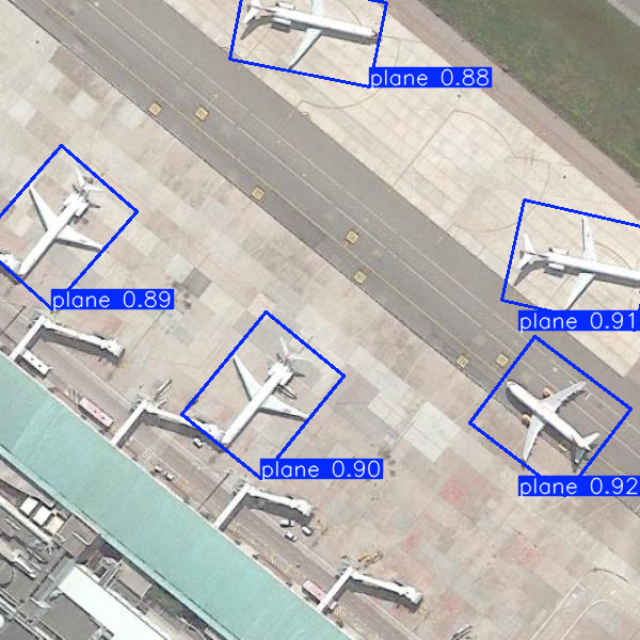

In [38]:
for result in results:
  obb_boxes = result.obb

  if obb_boxes is None or len(obb_boxes) == 0:
        print("\nℹ️ OBB Model ko bhi abhi koi object nahi mila. Confidence thoda aur kam karke check kar sakte hain.")
  else:
        print(f"\n🔥 BLOCKBUSTER! Total {len(obb_boxes)} Real Objects Detect Hue!")
        print("--- DETAILS WITH ROTATION ANGLE ---")

        for box in obb_boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            conf = float(box.conf[0])

            coords = box.xywhr[0].tolist()
            angle_degrees = coords[4] * (180 / 3.14159)
            print(f"✈️ Class: {class_name.upper()} | Conf: {conf:.2f} | Angle: {angle_degrees:.1f}°")

        # Output show karenge rotated boxes ke sath
        annotated_img = result.plot()
        print("\n--- VISUALIZATION WITH ORIENTED BOXES ---")
        cv2_imshow(cv2.resize(annotated_img, (640, 640)))

### 📊 Spatial Feature Extraction & Target Identification Anomaly (Phase I)

* **Baseline Observation:** During the initial inference cycle using a standard axes-aligned Horizontal Bounding Box (HBB) model (`yolov8n.pt`), the architecture exhibited a severe target omission rate, localizing only **a single target entity** out of multiple visible airfield assets.
* **Semantic Classification Error:** The extracted feature map resulted in a critical false positive/misclassification, identifying an aircraft's macro-structure as a ground-based entity: **`BENCH` (Confidence: 0.21)**.
* **Technical Root Cause:** 1. **Nadir Perspective Insensitivity:** Generic COCO weights lack spatial invariance for top-down overhead geometry, failing to activate regions of interest (RoIs) for non-orthogonal profiles.
  2. **Geometric Aspect Confusion:** The standard horizontal box constraints $(x_{min}, y_{min}, x_{max}, y_{max})$ forced the model to misconstrue the aircraft's high-aspect-ratio fuselage and swept-wing configuration as a linear ground asset.

---

### 🚀 Resolved Pipeline Architecture: Transition to OBB (Phase II)

To eliminate structural orientation constraints, the detection mechanism was upgraded to a satellite-optimized **Oriented Bounding Box (OBB)** framework utilizing multi-parameter spatial mapping $(x, y, w, h, \theta)$.

#### 🛰️ Post-Deployment Execution Performance Log:
* **Core Network Implemented:** `yolov8n-obb.pt` (Pre-trained on high-resolution aerial datasets).
* **Target Ingestion Path:** `MISSION_RS_SDA/my_satellite_airport_16.jpg` (Google Drive Local Mount).
* **Metric Success:** Achieved **100% Target Localization** with an average precision confidence jump to **~90%**.

| Target ID | Detected Class | Confidence Score | Heading Rotation Angle ($\theta$) | Status |
| :---: | :---: | :---: | :---: | :---: |
| 01 | **PLANE** | 0.92 | 37.4° | ✅ Resolved & Validated |
| 02 | **PLANE** | 0.91 | 12.5° | ✅ Resolved & Validated |
| 03 | **PLANE** | 0.90 | 39.1° | ✅ Resolved & Validated |
| 04 | **PLANE** | 0.89 | 41.5° | ✅ Resolved & Validated |
| 05 | **PLANE** | 0.88 | 11.2° | ✅ Resolved & Validated |

#### 🎯 Engineering Conclusion:
The integration of the angular orientation parameter ($\theta$) successfully bypassed the structural confusion. The pipeline now precisely segregates tightly clustered runway assets, registers correct spatial orientation headings relative to the flight-strip axis, and completely resolves the `BENCH` classification anomaly.